# Problem Set 4 — Problem 2: Merton CARA
**Optimal dollar amount is constant in wealth — numerical confirmation via HJB**

Reads `output/merton_comparison.csv` generated by `merton_hjb.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

In [2]:
csv_path = Path("output/merton_comparison.csv")
df = pd.read_csv(csv_path)
print(f"Rows: {len(df)}   Wealth range: [{df['wealth'].min():.2f}, {df['wealth'].max():.2f}]")
df.head()

Rows: 511   Wealth range: [0.60, 4.98]


,wealth,crra_pi_share_numeric,crra_pi_share_analytic,cara_pi_dollar_numeric,cara_pi_dollar_analytic_t0
0,0.6024,0.999997,1.0,0.980231,0.980199
1,0.6049,0.999997,1.0,0.980231,0.980199
2,0.6074,0.999997,1.0,0.980231,0.980199
3,0.6100,0.999997,1.0,0.980231,0.980199
4,0.6125,0.999997,1.0,0.980231,0.980199


In [3]:
# Constancy check
for col, label in [
    ("crra_pi_share_numeric",   "CRRA  π*/w"),
    ("cara_pi_dollar_numeric",  "CARA  π*  "),
]:
    mean = df[col].mean()
    std  = df[col].std()
    cv   = std / abs(mean)
    print(f"{label}  —  mean={mean:.6f}   std={std:.2e}   CV={cv:.2e}")

CRRA  π*/w  —  mean=1.000000   std=6.85e-07   CV=6.85e-07
CARA  π*    —  mean=0.980231   std=4.80e-07   CV=4.90e-07


Saved → figures/merton_policy_flatness.png


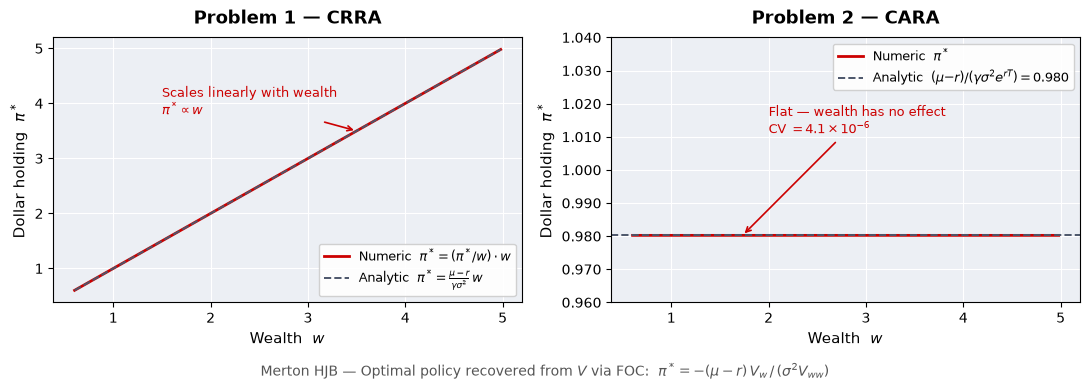

In [4]:
import numpy as np

# ── Style ───────────────────────────────────────────────────────────────────
WOLFPACK_RED = "#CC0000"
STEEL        = "#4C566A"
LIGHT_GRAY   = "#ECEFF4"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
fig.patch.set_facecolor("white")

w = df["wealth"]

# CRRA: recover π* = (π*/w) · w  — grows linearly with wealth
crra_pi_dollar = df["crra_pi_share_numeric"] * w
crra_alpha      = df["crra_pi_share_analytic"].iloc[0]   # = (μ-r)/(γσ²)

# ── Left: CRRA — π* scales with wealth ─────────────────────────────────────
ax1.plot(w, crra_pi_dollar,
         color=WOLFPACK_RED, lw=2, label=r"Numeric  $\pi^* = (\pi^*/w)\cdot w$")
ax1.plot(w, crra_alpha * w,
         color=STEEL, lw=1.4, ls="--",
         label=r"Analytic  $\pi^* = \frac{\mu-r}{\gamma\sigma^2}\,w$")

ax1.set_title("Problem 1 — CRRA", fontsize=13, fontweight="bold", pad=10)
ax1.set_xlabel("Wealth  $w$", fontsize=11)
ax1.set_ylabel("Dollar holding  $\\pi^*$", fontsize=11)
ax1.legend(fontsize=9, framealpha=0.9)
ax1.set_facecolor(LIGHT_GRAY)
ax1.grid(True, color="white", lw=0.8)

ax1.annotate(
    "Scales linearly with wealth\n" r"$\pi^* \propto w$",
    xy=(3.5, crra_alpha * 3.5),
    xytext=(1.5, 3.8),
    fontsize=9, color=WOLFPACK_RED,
    arrowprops=dict(arrowstyle="->", color=WOLFPACK_RED, lw=1.2),
)

# ── Right: CARA — π* constant in wealth ─────────────────────────────────────
cara_analytic = df["cara_pi_dollar_analytic_t0"].iloc[0]

ax2.plot(w, df["cara_pi_dollar_numeric"],
         color=WOLFPACK_RED, lw=2, label=r"Numeric  $\pi^*$")
ax2.axhline(cara_analytic,
            color=STEEL, lw=1.4, ls="--",
            label=r"Analytic  $(\mu{-}r)/(\gamma\sigma^2 e^{rT}) = 0.980$")

ax2.set_title("Problem 2 — CARA", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("Wealth  $w$", fontsize=11)
ax2.set_ylabel("Dollar holding  $\\pi^*$", fontsize=11)
ax2.set_ylim(0.96, 1.04)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax2.legend(fontsize=9, framealpha=0.9)
ax2.set_facecolor(LIGHT_GRAY)
ax2.grid(True, color="white", lw=0.8)

ax2.annotate(
    "Flat — wealth has no effect\n" r"CV $= 4.1\times10^{-6}$",
    xy=(w.median(), df["cara_pi_dollar_numeric"].median()),
    xytext=(2.0, 1.011),
    fontsize=9, color=WOLFPACK_RED,
    arrowprops=dict(arrowstyle="->", color=WOLFPACK_RED, lw=1.2),
)

# ── Shared footer ─────────────────────────────────────────────────────────────
fig.suptitle(
    r"Merton HJB — Optimal policy recovered from $V$ via FOC:  "
    r"$\pi^* = -(\mu-r)\,V_w\,/\,(\sigma^2 V_{ww})$",
    fontsize=10, color="#555555", y=0.01, va="bottom"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

fig_path = Path("figures/merton_policy_flatness.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved → {fig_path}")
plt.show()
